# Notebook 04 — Oportunidade de Expansão de Capacidade em Entregas
## M&A em Logística B2B: Projeção de Ganhos de Capacidade com Roteirizador da LogiPrime

**Objetivo:** Projetar o potencial de expansão da capacidade operacional em número de entregas para cada rota em 2024 da RotaSul, utilizando as alavancas de otimização de tempo fornecidas pelo roteirizador da LogiPrime. O notebook identifica as restrições operacionais críticas (tempo de jornada, capacidade de peso e capacidade volumétrica) e projeta os ganhos efetivos por rota via *minimum rule*, o gargalo mais restritivo determina o potencial real de cada rota.

**Dados:** 62.800 rotas únicas da RotaSul em 2024 | PR, SC, RS | TRUCK e CARRETA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Configurar matplotlib — padrão idêntico ao NB01–03
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

# Diretórios
BASE_DIR = Path('..').resolve()
DATA_PROCESSED = BASE_DIR / 'data' / '03_processed'
RESULTS_DIR = BASE_DIR / 'results' / '04_entregas'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Base dir: {BASE_DIR}")
print(f"Results dir: {RESULTS_DIR}")

Base dir: D:\UERJ\Programacao_e_Codigos\PRG00_Case M&A em Logistica
Results dir: D:\UERJ\Programacao_e_Codigos\PRG00_Case M&A em Logistica\results\04_entregas


---
## Seção 0 — Setup e Premissas

Esta seção declara todas as premissas do modelo de forma explícita e rastreável. As constantes de otimização são herdadas do Notebook 03 sem alteração, garantindo consistência analítica entre os dois notebooks. As constantes de capacidade física (peso e volume por tipo de veículo) são premissas novas e exclusivas deste notebook, necessárias para modelar as restrições físicas da frota.

### 0.1 — Premissas Herdadas do Notebook 03

As três alavancas de otimização abaixo são as mesmas utilizadas no NB03. Nenhuma premissa de otimização nova é introduzida a base analítica é compartilhada.

In [3]:
# ALAVANCAS DE OTIMIZAÇÃO DO ROTEIRIZADOR DA LOGIPRIME
# Premissas herdadas do Notebook 03 — não alterar sem sincronizar com NB03
REDUCAO_TEMPO_TRECHO = 0.23    # 23% de redução no tempo de deslocamento
REDUCAO_TEMPO_ESPERA = 0.35    # 35% de redução no tempo de espera no PDV
JORNADA_PADRAO_MIN   = 440     # Jornada padrão em minutos (7h20)

print("Premissas herdadas do NB03:")
print(f"  Redução tempo trecho : {REDUCAO_TEMPO_TRECHO:.0%}")
print(f"  Redução tempo espera : {REDUCAO_TEMPO_ESPERA:.0%}")
print(f"  Jornada padrão       : {JORNADA_PADRAO_MIN} min")

Premissas herdadas do NB03:
  Redução tempo trecho : 23%
  Redução tempo espera : 35%
  Jornada padrão       : 440 min


### 0.2 — Premissas Exclusivas do Notebook 04

As capacidades físicas da frota (peso máximo e volume máximo por tipo de veículo) são necessárias para calcular a restrição física de cada rota. Os valores confirmam as capacidades da frota RotaSul: TRUCKs com 12 t e 60 m³, CARRETAs com 25 t e 100 m³.



In [4]:
# CAPACIDADES FÍSICAS DA FROTA ROTASUL
# Confirmadas via dados: peso_total / ocup_kg = capacidade_max (variação < 1e-10)
CAPACIDADES = {
    'TRUCK':   {'peso_kg': 12_000, 'volume_m3': 60},
    'CARRETA': {'peso_kg': 25_000, 'volume_m3': 100},
}

print("Capacidades da frota RotaSul:")
for veiculo, cap in CAPACIDADES.items():
    print(f"  {veiculo:8s}: {cap['peso_kg']:,} kg | {cap['volume_m3']} m³")


Capacidades da frota RotaSul:
  TRUCK   : 12,000 kg | 60 m³
  CARRETA : 25,000 kg | 100 m³


### 0.3 — Carregamento de Dados e Construção da Base de Cálculo (Nível Rota)

Os dados são carregados diretamente do parquet processado pelo Notebook 01, filtrando apenas registros da RotaSul. A construção da base no nível rota replica o `groupby` do NB03. Cada `codigo_rota` se torna uma linha única com as métricas consolidadas da rota.

As otimizações de tempo são aplicadas neste bloco para garantir que toda análise subsequente parta das mesmas colunas derivadas.

In [5]:
# Colunas necessárias para o NB04
COLS = [
    'empresa', 'codigo_rota', 'data_rota', 'uf', 'tipo_veiculo', 'placa_veiculo',
    'km_total_rota', 'km_retorno_base',
    'tempo_trecho_min', 'tempo_espera_pdv_min', 'tempo_descarga_pdv_min',
    'peso_kg_total_rota', 'volume_m3_total_rota',
    'num_entregas_rota',
    'ocup_kg_rota', 'ocup_vol_rota',
]

df_raw = pd.read_parquet(
    DATA_PROCESSED / 'dados_limpos.parquet',
    columns=COLS,
    filters=[('empresa', '==', 'RotaSul')]
)

print(f"Registros carregados (RotaSul): {len(df_raw):,}")
print(f"Rotas únicas                  : {df_raw['codigo_rota'].nunique():,}")

Registros carregados (RotaSul): 438,788
Rotas únicas                  : 62,800


In [6]:
# Construir base no nível rota — uma linha por codigo_rota
df_rotas = df_raw.groupby('codigo_rota', as_index=False).agg(
    data_rota          = ('data_rota',           'first'),
    uf                 = ('uf',                  'first'),
    tipo_veiculo       = ('tipo_veiculo',         'first'),
    placa_veiculo      = ('placa_veiculo',        'first'),
    km_total_rota      = ('km_total_rota',        'first'),
    km_retorno_base    = ('km_retorno_base',      'first'),
    tempo_trecho_min   = ('tempo_trecho_min',     'sum'),
    tempo_espera_pdv_min  = ('tempo_espera_pdv_min', 'sum'),
    tempo_descarga_pdv_min= ('tempo_descarga_pdv_min','sum'),
    peso_kg_total_rota = ('peso_kg_total_rota',  'first'),
    volume_m3_total_rota= ('volume_m3_total_rota','first'),
    num_entregas_rota  = ('num_entregas_rota',   'first'),
    ocup_kg_rota       = ('ocup_kg_rota',        'first'),
    ocup_vol_rota      = ('ocup_vol_rota',       'first'),
)

df_rotas['km_retorno_base'] = df_rotas['km_retorno_base'].fillna(0)

assert (df_rotas['num_entregas_rota'] > 0).all(), "Existem rotas com num_entregas_rota == 0"

# ── Tempo atual ──────────────────────────────────────────────────────────────
df_rotas['tempo_total_rota_min'] = (
    df_rotas['tempo_trecho_min'] +
    df_rotas['tempo_espera_pdv_min'] +
    df_rotas['tempo_descarga_pdv_min']
)
df_rotas['minutos_he_atuais'] = np.maximum(
    0, df_rotas['tempo_total_rota_min'] - JORNADA_PADRAO_MIN
)
df_rotas['flag_he_atual'] = df_rotas['minutos_he_atuais'] > 0

# ── Tempo otimizado (alavancas do roteirizador) ───────────────────────────────
df_rotas['tempo_trecho_otimizado_min'] = df_rotas['tempo_trecho_min'] * (1 - REDUCAO_TEMPO_TRECHO)
df_rotas['tempo_espera_otimizado_min'] = df_rotas['tempo_espera_pdv_min'] * (1 - REDUCAO_TEMPO_ESPERA)
df_rotas['tempo_total_otimizado_min']  = (
    df_rotas['tempo_trecho_otimizado_min'] +
    df_rotas['tempo_espera_otimizado_min'] +
    df_rotas['tempo_descarga_pdv_min']
)
df_rotas['tempo_liberado_min'] = np.maximum(
    0,
    df_rotas['tempo_total_rota_min'] - df_rotas['tempo_total_otimizado_min']
)

print(f"Base de cálculo construída: {len(df_rotas):,} rotas únicas")
print(f"\nMétricas principais (RotaSul):")
print(f"  Rotas em hora extra         : {df_rotas['flag_he_atual'].sum():,} ({df_rotas['flag_he_atual'].mean():.1%})")
print(f"  Tempo liberado médio/rota   : {df_rotas['tempo_liberado_min'].mean():.1f} min")
print(f"  Tempo liberado total        : {df_rotas['tempo_liberado_min'].sum():,.0f} min ({df_rotas['tempo_liberado_min'].sum()/60:,.0f} h)")
df_rotas[['uf','tipo_veiculo','tempo_total_rota_min','tempo_total_otimizado_min','tempo_liberado_min']].head(3)

Base de cálculo construída: 62,800 rotas únicas

Métricas principais (RotaSul):
  Rotas em hora extra         : 35,446 (56.4%)
  Tempo liberado médio/rota   : 91.5 min
  Tempo liberado total        : 5,748,001 min (95,800 h)


,uf,tipo_veiculo,tempo_total_rota_min,tempo_total_otimizado_min,tempo_liberado_min
0,PR,CARRETA,456.797764,372.677628,84.120135
1,PR,CARRETA,379.739425,304.275395,75.464030
2,PR,CARRETA,580.419757,455.320096,125.099661


---
## Seção 1 — Construção da Métrica de Tempo por Entrega

Esta seção é o alicerce analítico do notebook. Antes de projetar entregas adicionais, é preciso saber quanto tempo cada entrega atual consome. Essa será a unidade de conversão entre "tempo liberado" e "entregas adicionais possíveis".

Duas abordagens são definidas e mantidas em paralelo ao longo do notebook:
- **Abordagem A (conservadora):** usa o tempo médio atual por entrega, que inclui o overhead do deslocamento inicial (*First Mile*). Tende a subestimar o potencial de expansão.
- **Abordagem B (otimista):** usa o tempo marginal de uma entrega adicional inserida no corredor existente, excluindo ~50% do componente de trecho como proxy do *First Mile*. Mais realista para entregas incrementais.

### 1.1 — Tempo por Entrega Atual e Tempo Marginal

O `tempo_por_entrega_atual` divide o tempo total da rota pelo número de paradas,  capturando quanto tempo, em média, cada entrega consome naquela rota, incluindo deslocamento, espera e descarga proporcionais.

O `tempo_marginal_por_entrega` é calculado com base nos componentes de espera e descarga (que se repetem integralmente para cada parada adicional) mais apenas 50% do componente de trecho (proxy para o trecho incremental dentro do corredor, sem o *First Mile*).

In [7]:
# Abordagem A: tempo médio atual por entrega (conservadora) 
df_rotas['tempo_trecho_por_entrega']   = df_rotas['tempo_trecho_min']      / df_rotas['num_entregas_rota']
df_rotas['tempo_espera_por_entrega']   = df_rotas['tempo_espera_pdv_min']  / df_rotas['num_entregas_rota']
df_rotas['tempo_descarga_por_entrega'] = df_rotas['tempo_descarga_pdv_min']/ df_rotas['num_entregas_rota']

df_rotas['tempo_por_entrega_atual'] = (
    df_rotas['tempo_total_rota_min'] / df_rotas['num_entregas_rota']
)

# Abordagem B: tempo marginal (otimista) 
# Exclui ~50% do trecho como proxy do overhead de First Mile
df_rotas['tempo_marginal_por_entrega'] = (
    df_rotas['tempo_espera_por_entrega'] +
    df_rotas['tempo_descarga_por_entrega'] +
    df_rotas['tempo_trecho_por_entrega'] * 0.5
)

print("Tempo por entrega (mediana, por tipo de veículo):")
print(df_rotas.groupby('tipo_veiculo')[
    ['tempo_por_entrega_atual', 'tempo_marginal_por_entrega']
].median().round(1))

Tempo por entrega (mediana, por tipo de veículo):
              tempo_por_entrega_atual  tempo_marginal_por_entrega
tipo_veiculo                                                     
CARRETA                          66.8                        47.4
TRUCK                            66.8                        47.4


- O ponto de partida analítico do notebook é a definição de uma unidade de conversão entre tempo liberado e entregas adicionais possíveis, afim de levar em consideração para análise quanto tempo em média cada entrega consome em uma rota. Essa métrica é calculada de duas formas complementares, mantidas em paralelo ao longo de toda a análise.
    - Abordagem A (conservadora) divide o tempo total da rota somando trecho, espera e descarga, pelo número de paradas, capturando o custo médio completo de cada entrega, inclusive a parcela proporcional do deslocamento inicial (First Mile).
    - Abordagem B (otimista) isola o custo marginal de uma entrega adicional inserida no corredor existente, onde utiliza integralmente os componentes de espera e descarga por parada, mas aplica apenas 50% do componente de trecho como proxy do trecho incremental, excluindo o overhead do First Mile, que não se repete para entregas adicionais na mesma rota.

### 1.2 — Distribuição Estatística do Tempo por Entrega

A distribuição do tempo por entrega varia significativamente por tipo de veículo e estado. Rotas de CARRETA com poucas paradas tendem a ter tempo por entrega muito alto (grande deslocamento entre clientes), enquanto rotas de TRUCK com muitas paradas concentradas têm tempo por entrega menor. Esse perfil determina quanto tempo liberado cada tipo de rota consegue converter em entregas adicionais.

In [8]:
# Tabela P25 / P50 / P75 / P90 por tipo de veículo e UF
def tabela_percentis(df, col, groupby_col):
    return df.groupby(groupby_col)[col].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90]
    )[['25%', '50%', '75%', '90%', 'mean']].round(1)

print("=== Tempo por Entrega Atual (min) — por Tipo de Veículo ===")
print(tabela_percentis(df_rotas, 'tempo_por_entrega_atual', 'tipo_veiculo'))
print()
print("=== Tempo por Entrega Atual (min) — por UF ===")
print(tabela_percentis(df_rotas, 'tempo_por_entrega_atual', 'uf'))
print()
print("=== Tempo Marginal por Entrega (min) — por Tipo de Veículo ===")
print(tabela_percentis(df_rotas, 'tempo_marginal_por_entrega', 'tipo_veiculo'))

=== Tempo por Entrega Atual (min) — por Tipo de Veículo ===
               25%   50%   75%    90%  mean
tipo_veiculo                               
CARRETA       52.7  66.8  86.0  111.7  74.3
TRUCK         52.6  66.8  85.9  111.7  74.2

=== Tempo por Entrega Atual (min) — por UF ===
     25%   50%   75%    90%  mean
uf                               
PR  52.7  66.8  86.1  112.0  74.5
RS  52.7  66.9  85.5  111.2  74.0
SC  52.5  66.7  86.1  111.7  74.3

=== Tempo Marginal por Entrega (min) — por Tipo de Veículo ===
               25%   50%   75%   90%  mean
tipo_veiculo                              
CARRETA       40.1  47.4  57.3  70.7  51.2
TRUCK         40.0  47.4  57.2  70.7  51.2


- Os resultados revelam uma homogeneidade expressiva entre os segmentos da frota. A mediana do tempo por entrega atual é de 66,8 minutos tanto para TRUCKs quanto para CARRETAs, e praticamente idêntica entre PR (74,5 min de média), SC (74,3 min) e RS (74,0 min). A mediana do tempo marginal é de 47,4 minutos para ambos os tipos de veículo, o que mostra uma diferença de ~29% em relação à abordagem conservadora, que traduz precisamente o peso do componente de deslocamento no tempo total de rota.

### 1.3 — Visualização: Distribuição do Tempo por Entrega

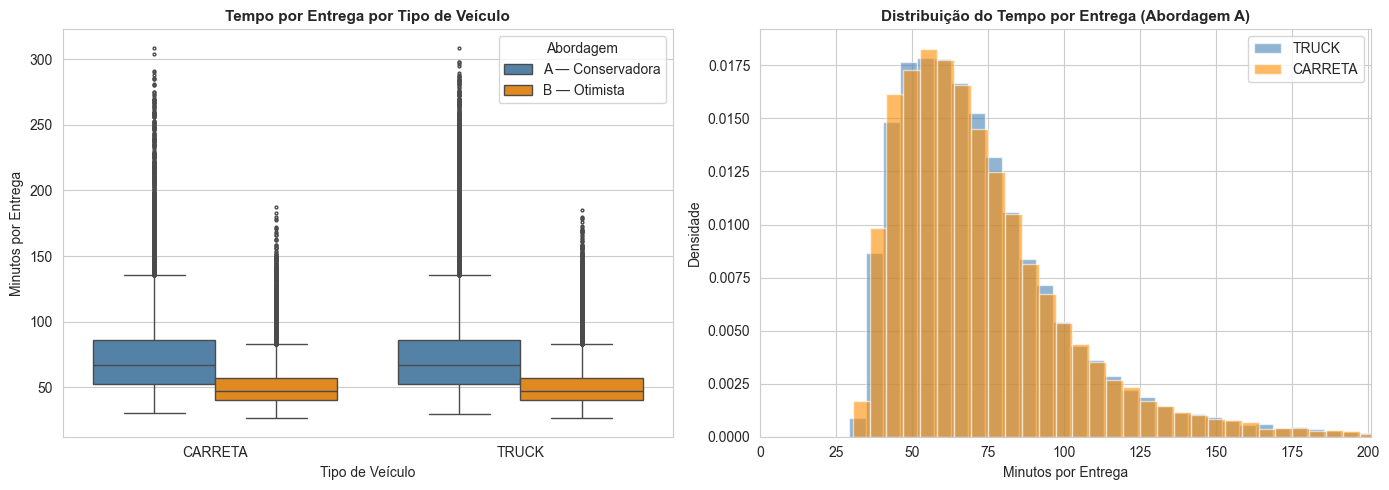

Figura salva: 01_distribuicao_tempo_por_entrega.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por tipo de veículo
ax1 = axes[0]
df_plot = df_rotas[['tipo_veiculo', 'tempo_por_entrega_atual', 'tempo_marginal_por_entrega']].melt(
    id_vars='tipo_veiculo',
    value_vars=['tempo_por_entrega_atual', 'tempo_marginal_por_entrega'],
    var_name='Abordagem',
    value_name='Minutos'
)
df_plot['Abordagem'] = df_plot['Abordagem'].map({
    'tempo_por_entrega_atual': 'A — Conservadora',
    'tempo_marginal_por_entrega': 'B — Otimista'
})
sns.boxplot(data=df_plot, x='tipo_veiculo', y='Minutos', hue='Abordagem',
            ax=ax1, palette=['steelblue', 'darkorange'], flierprops={'markersize': 2})
ax1.set_title('Tempo por Entrega por Tipo de Veículo', fontsize=11, fontweight='bold')
ax1.set_xlabel('Tipo de Veículo')
ax1.set_ylabel('Minutos por Entrega')
ax1.legend(title='Abordagem')

# Histograma de distribuição — Abordagem A
ax2 = axes[1]
for veiculo, cor in zip(['TRUCK', 'CARRETA'], ['steelblue', 'darkorange']):
    subset = df_rotas[df_rotas['tipo_veiculo'] == veiculo]['tempo_por_entrega_atual']
    ax2.hist(subset, bins=50, alpha=0.6, color=cor, label=veiculo, density=True)
ax2.set_title('Distribuição do Tempo por Entrega (Abordagem A)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Minutos por Entrega')
ax2.set_ylabel('Densidade')
ax2.legend()
ax2.set_xlim(0, df_rotas['tempo_por_entrega_atual'].quantile(0.99))

plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_distribuicao_tempo_por_entrega.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: 01_distribuicao_tempo_por_entrega.png")

-  A distribuição apresenta cauda longa à direita (P90 em ~111–112 minutos), indicando a existência de rotas com baixo número de paradas e longos trechos entre clientes, justamente aquelas onde o custo de inserir uma entrega adicional é mais alto. 

- A decisão metodológica de manter as duas abordagens em paralelo é tecnicamente sólida, pois ela evita que o modelo apresente um único número como verdade, e permite compreender o intervalo de estimativa antes mesmo de aplicar as restrições físicas. 

---
## Seção 2 — Tempo Aproveitável por Rota

O tempo liberado pelo roteirizador não é inteiramente disponível para novas entregas. Para rotas que já estavam em hora extra, o tempo liberado primeiro "quita" o excedente de jornada, e então, só o que sobrar além da correção da HE é aproveitável para entregas adicionais. Para rotas dentro da jornada, todo o tempo liberado é aproveitável, respeitando o teto de 440 minutos.

Esta distinção é crítica e diferencia esta análise do NB03, pois lá, o tempo liberado era convertido diretamente em saving de HE. Aqui, ele precisa ser reclassificado. As duas parcelas são mutuamente exclusivas.

### 2.1 — Cálculo do Tempo Aproveitável

A lógica bifurca em dois caminhos:

- **Rotas em HE:** `tempo_aproveitavel = max(0, tempo_liberado - minutos_he_atuais)` : o tempo liberado primeiro elimina a hora extra antes de liberar capacidade produtiva.
- **Rotas dentro da jornada:** `tempo_aproveitavel = min(tempo_liberado, 440 - tempo_total_otimizado)` : todo o tempo liberado está disponível, limitado ao teto da jornada padrão.

Sendo assim, A lógica garante a não dupla contagem entre os dois notebooks. Para as 35.446 rotas em hora extra (56,4% da base), o tempo aproveitável é max(0, tempo_liberado − minutos_HE_atuais), ou seja, a otimização primeiro elimina o estouro de jornada (valor contabilizado como saving no NB03) e só então libera tempo produtivo. Para as 27.354 rotas dentro da jornada, todo o tempo liberado é aproveitável, limitado ao teto de 440 minutos.

In [10]:
# 2.1 Cálculo do tempo aproveitável por rota
df_rotas['tempo_aproveitavel_min'] = np.where(
    df_rotas['flag_he_atual'],
    np.maximum(0, df_rotas['tempo_liberado_min'] - df_rotas['minutos_he_atuais']),
    np.minimum(df_rotas['tempo_liberado_min'], JORNADA_PADRAO_MIN - df_rotas['tempo_total_otimizado_min'])
)
df_rotas['tempo_aproveitavel_min'] = df_rotas['tempo_aproveitavel_min'].clip(lower=0)

n_aproveitavel = (df_rotas['tempo_aproveitavel_min'] > 0).sum()
pct_aproveitavel = n_aproveitavel / len(df_rotas)

print(f"Rotas com tempo aproveitável > 0 : {n_aproveitavel:,} ({pct_aproveitavel:.1%})")
print(f"Tempo aproveitável total         : {df_rotas['tempo_aproveitavel_min'].sum():,.0f} min ({df_rotas['tempo_aproveitavel_min'].sum()/60:,.0f} h)")
print(f"Tempo aproveitável médio/rota    : {df_rotas['tempo_aproveitavel_min'].mean():.1f} min")
print()
print("=== Tempo Aproveitável Médio por UF e Tipo de Veículo ===")
print(df_rotas.groupby(['uf', 'tipo_veiculo'])['tempo_aproveitavel_min'].agg(['mean','median','sum']).round(1))

Rotas com tempo aproveitável > 0 : 45,194 (72.0%)
Tempo aproveitável total         : 2,580,644 min (43,011 h)
Tempo aproveitável médio/rota    : 41.1 min

=== Tempo Aproveitável Médio por UF e Tipo de Veículo ===
                 mean  median       sum
uf tipo_veiculo                        
PR CARRETA       41.1    49.1  309549.6
   TRUCK         40.9    48.8  723489.8
RS CARRETA       41.2    49.2  229278.3
   TRUCK         41.2    49.4  538469.7
SC CARRETA       41.3    49.0  237471.7
   TRUCK         41.1    48.9  542385.4


- O resultado após essa reclassificação é significativo, uma vez que 45.194 rotas (72,0%) apresentam tempo aproveitável positivo, com média de 41,1 minutos por rota e total de 2,58 milhões de minutos (43.011 horas) disponíveis para conversão em entregas adicionais ao longo de 2024. Vale notar que das 17.840 rotas em hora extra com tempo aproveitável positivo, isso significa que o tempo liberado pelo roteirizador superou o próprio excedente de jornada, ou seja, o ganho de otimização foi grande o suficiente tanto para eliminar a HE quanto para sobrar margem produtiva.

- A distribuição do tempo aproveitável é notavelmente uniforme entre UFs e tipos de veículo, com médias entre 40,9 e 41,3 minutos em todos os seis segmentos, com medianas entre 48,8 e 49,4 minutos. Essa homogeneidade reflete o padrão padronizado da operação Sul, e é um indicativo positivo para o rollout do roteirizador, já que o benefício de capacidade não se concentra em apenas um estado ou tipo de frota, ela está distribuído de forma equilibrada por toda a operação.

### 2.2 — Visualização: Distribuição do Tempo Aproveitável

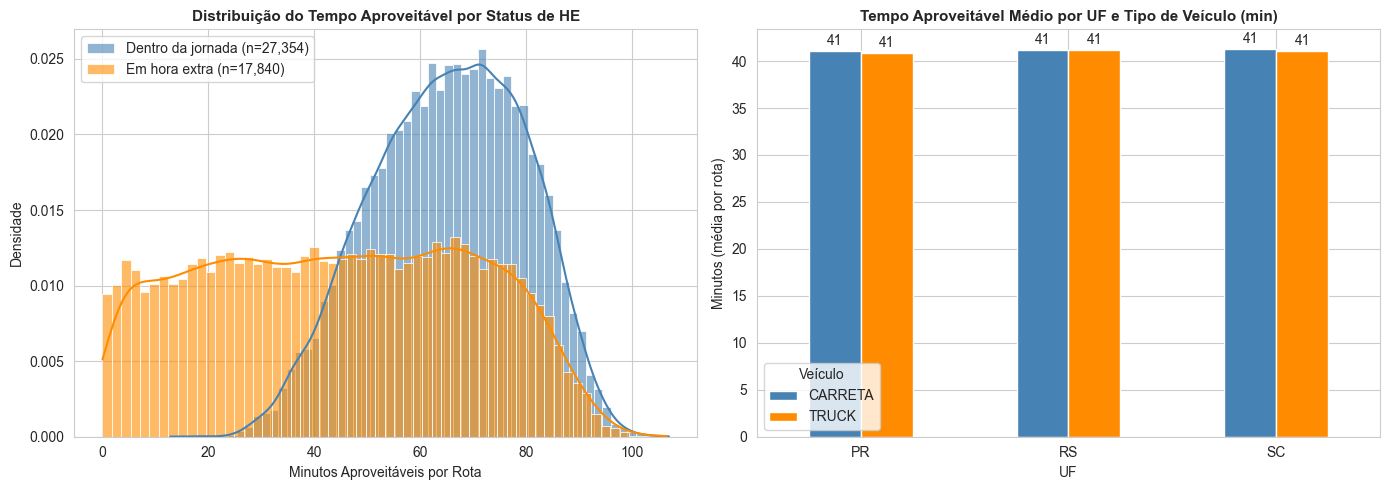

Figura salva: 02_tempo_aproveitavel_distribuicao.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
df_he   = df_rotas[df_rotas['flag_he_atual']  & (df_rotas['tempo_aproveitavel_min'] > 0)]['tempo_aproveitavel_min']
df_nhe  = df_rotas[~df_rotas['flag_he_atual'] & (df_rotas['tempo_aproveitavel_min'] > 0)]['tempo_aproveitavel_min']

sns.histplot(df_nhe, bins=60, alpha=0.6, color='steelblue', label=f'Dentro da jornada (n={len(df_nhe):,})', kde=True, stat='density', ax=ax1)
sns.histplot(df_he,  bins=60, alpha=0.6, color='darkorange', label=f'Em hora extra (n={len(df_he):,})', kde=True, stat='density', ax=ax1)
ax1.set_title('Distribuição do Tempo Aproveitável por Status de HE', fontsize=11, fontweight='bold')
ax1.set_xlabel('Minutos Aproveitáveis por Rota')
ax1.set_ylabel('Densidade')
ax1.legend()

ax2 = axes[1]
resumo = df_rotas.groupby(['uf', 'tipo_veiculo'])['tempo_aproveitavel_min'].mean().unstack()
resumo.plot(kind='bar', ax=ax2, color=['steelblue', 'darkorange'])
ax2.set_title('Tempo Aproveitável Médio por UF e Tipo de Veículo (min)', fontsize=11, fontweight='bold')
ax2.set_xlabel('UF')
ax2.set_ylabel('Minutos (média por rota)')
ax2.tick_params(axis='x', rotation=0)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.0f', padding=2)
ax2.legend(title='Veículo')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '02_tempo_aproveitavel_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: 02_tempo_aproveitavel_distribuicao.png")

---
## Seção 3 — Projeção de Entregas Adicionais por Tempo

Com o tempo aproveitável calculado e a unidade de conversão (tempo por entrega) definida, é possível projetar quantas entregas adicionais cada rota poderia absorver considerando apenas a restrição de jornada. Esta seção apresenta os dois cenários (conservador e otimista) antes da aplicação das restrições físicas de peso e volume, que serão incorporadas na Seção 4.


### 3.1 — Entregas Adicionais por Rota: Cenário Conservador e Otimista

O **cenário conservador** usa o tempo médio atual por entrega como denominador (tempo maior), portanto projeta menos entregas adicionais. O **cenário otimista** usa o tempo marginal (tempo menor), logo, ele projeta mais entregas por aproveitar que entregas incrementais no corredor existente não carregam o overhead do *First Mile*.

In [12]:
# 3.1 Cálculo do número de entregas adicionais possíveis
df_rotas['entregas_adicionais_tempo_cons'] = np.floor(
    df_rotas['tempo_aproveitavel_min'] / df_rotas['tempo_por_entrega_atual']
).astype(int)

df_rotas['entregas_adicionais_tempo_otim'] = np.floor(
    df_rotas['tempo_aproveitavel_min'] / df_rotas['tempo_marginal_por_entrega']
).astype(int)

df_rotas['entregas_adicionais_tempo_cons'] = df_rotas['entregas_adicionais_tempo_cons'].clip(lower=0)
df_rotas['entregas_adicionais_tempo_otim'] = df_rotas['entregas_adicionais_tempo_otim'].clip(lower=0)

for cenario, col in [('Conservador', 'entregas_adicionais_tempo_cons'), ('Otimista', 'entregas_adicionais_tempo_otim')]:
    n1 = (df_rotas[col] >= 1).sum()
    n2 = (df_rotas[col] >= 2).sum()
    n5 = (df_rotas[col] >= 5).sum()
    total = df_rotas[col].sum()
    print(f"=== Cenário {cenario} ===")
    print(f"  Rotas com ≥1 entrega adicional : {n1:,} ({n1/len(df_rotas):.1%})")
    print(f"  Rotas com ≥2 entregas adicionais: {n2:,} ({n2/len(df_rotas):.1%})")
    print(f"  Rotas com ≥5 entregas adicionais: {n5:,} ({n5/len(df_rotas):.1%})")
    print(f"  Total entregas adicionais        : {total:,}")
    print()

=== Cenário Conservador ===
  Rotas com ≥1 entrega adicional : 20,035 (31.9%)
  Rotas com ≥2 entregas adicionais: 101 (0.2%)
  Rotas com ≥5 entregas adicionais: 0 (0.0%)
  Total entregas adicionais        : 20,136

=== Cenário Otimista ===
  Rotas com ≥1 entrega adicional : 31,035 (49.4%)
  Rotas com ≥2 entregas adicionais: 2,411 (3.8%)
  Rotas com ≥5 entregas adicionais: 0 (0.0%)
  Total entregas adicionais        : 33,446



- No cenário conservador (Abordagem A), 20.035 rotas (31,9%) ganham ao menos uma entrega adicional por rota, com total projetado de 20.136 entregas adicionais. Apenas 101 rotas (0,2%) chegam a duas entregas adicionais, e nenhuma atinge cinco ou mais. No cenário otimista (Abordagem B), o potencial sobe para 33.446 entregas adicionais, com 31.035 rotas (49,4%) ganhando ao menos uma entrega e 2.411 rotas (3,8%) chegando a duas.

- A diferença de ~66% entre os dois cenários (20.136 versus 33.446), quantifica o impacto da hipótese sobre o custo marginal das entregas incrementais. Esse intervalo é a faixa de incerteza analítica da projeção antes das restrições físicas, e precisa ser comunicado ao time de negócios como tal. O número real de entregas adicionais possíveis se situará dentro desse intervalo dependendo de como o roteirizador efetivamente redesenha os corredores de entrega na prática.

### 3.2 — Visualização: Histograma de Entregas Adicionais por Tempo

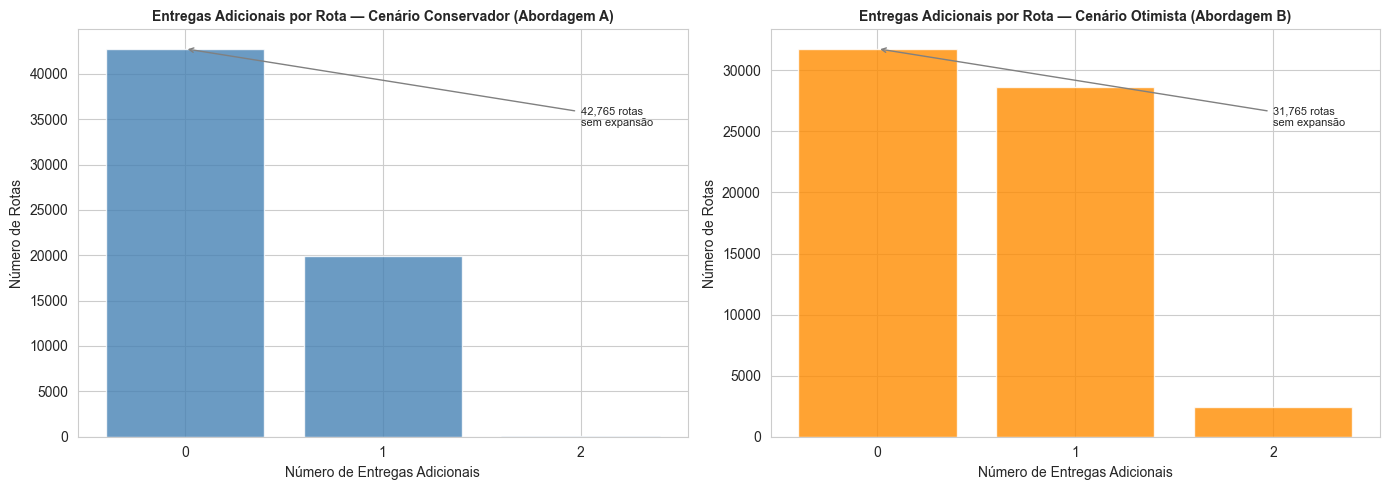

Figura salva: 03_entregas_adicionais_histograma.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = range(0, int(df_rotas['entregas_adicionais_tempo_otim'].quantile(0.98)) + 2)

for ax, col, titulo, cor in [
    (axes[0], 'entregas_adicionais_tempo_cons', 'Cenário Conservador (Abordagem A)', 'steelblue'),
    (axes[1], 'entregas_adicionais_tempo_otim', 'Cenário Otimista (Abordagem B)', 'darkorange'),
]:
    contagens = df_rotas[col].value_counts().sort_index()
    contagens = contagens[contagens.index <= max(bins)-1]
    ax.bar(contagens.index, contagens.values, color=cor, alpha=0.8, width=0.8)
    ax.set_title(f'Entregas Adicionais por Rota — {titulo}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Número de Entregas Adicionais')
    ax.set_ylabel('Número de Rotas')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    n0 = (df_rotas[col] == 0).sum()
    ax.annotate(f'{n0:,} rotas\nsem expansão', xy=(0, n0), xytext=(2, n0 * 0.8),
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / '03_entregas_adicionais_histograma.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: 03_entregas_adicionais_histograma.png")

---
## Seção 4 — Restrições Operacionais Críticas e Minimum Rule

Esta é a seção que mais diferencia este notebook do NB03 e que demonstra maturidade analítica. Uma rota pode ter tempo disponível, mas o veículo pode estar fisicamente lotado em peso ou volume, o que nesse caso, nenhuma entrega adicional é possível independentemente da folga de jornada.

A *minimum rule* estabelece que a entrega adicional projetada é limitada pelo menor dos três tetos simultaneamente: 
- tempo de jornada, 
- capacidade de peso, 
- capacidade volumétrica. 

O gargalo ativo em cada rota determina qual investimento desbloquearia mais entregasm, o que torna uma informação direta para decisões de Capex.

### 4.1 — Restrição de Capacidade de Peso

Para cada rota, o peso disponível é a diferença entre a capacidade máxima do veículo e o peso já carregado. Dividindo pelo peso médio por entrega atual, obtemos quantas entregas adicionais o veículo suporta em peso.

Os dados do Notebook 02 indicaram que os TRUCKs da RotaSul operam a ~64% de ocupação de peso e as CARRETAs a ~67%, portanto, há margem significativa de capacidade de peso na frota.

In [14]:
# 4.1 Cálculo do número de entregas adicionais possíveis — restrição de peso
df_rotas['capacidade_max_peso_kg']   = df_rotas['tipo_veiculo'].map({v: c['peso_kg']   for v, c in CAPACIDADES.items()})
df_rotas['capacidade_max_volume_m3'] = df_rotas['tipo_veiculo'].map({v: c['volume_m3'] for v, c in CAPACIDADES.items()})

df_rotas['peso_disponivel_kg']      = np.maximum(0, df_rotas['capacidade_max_peso_kg'] - df_rotas['peso_kg_total_rota'])
df_rotas['peso_medio_por_entrega']  = df_rotas['peso_kg_total_rota'] / df_rotas['num_entregas_rota']
df_rotas['entregas_adicionais_peso'] = np.floor(df_rotas['peso_disponivel_kg'] / df_rotas['peso_medio_por_entrega']).clip(lower=0).astype(int)

print("Restrição de Peso — estatísticas:")
print(f"  Ocupação média de peso  — TRUCK  : {df_rotas[df_rotas['tipo_veiculo']=='TRUCK']['ocup_kg_rota'].mean():.1%}")
print(f"  Ocupação média de peso  — CARRETA: {df_rotas[df_rotas['tipo_veiculo']=='CARRETA']['ocup_kg_rota'].mean():.1%}")
print(f"  Entregas adicionais possíveis (peso) — mediana: {df_rotas['entregas_adicionais_peso'].median():.0f}")

Restrição de Peso — estatísticas:
  Ocupação média de peso  — TRUCK  : 75.0%
  Ocupação média de peso  — CARRETA: 75.0%
  Entregas adicionais possíveis (peso) — mediana: 2


- Para a restrição de peso, a ocupação média da frota é de 75,0% tanto para TRUCKs quanto para CARRETAs, resultando em uma margem disponível de 25% sobre a capacidade máxima (12.000 kg e 25.000 kg, respectivamente). Dividindo o peso disponível pelo peso médio por entrega da rota, a mediana de entregas adicionais possíveis pela dimensão peso é de 2 por rota, indicando folga física razoável.

### 4.2 — Restrição de Capacidade Volumétrica

Mesma lógica aplicada ao volume. Os dados do Notebook 02 (Pilar 2) mostraram que a RotaSul opera em regime predominantemente *Cube-out* , onde o volume é o fator limitante mais frequente da frota. Isso sugere que a restrição volumétrica será o gargalo físico dominante para entregas adicionais na maioria das rotas.

In [15]:
# 4.2 Cálculo do número de entregas adicionais possíveis — restrição de volume
df_rotas['volume_disponivel_m3']       = np.maximum(0, df_rotas['capacidade_max_volume_m3'] - df_rotas['volume_m3_total_rota'])
df_rotas['volume_medio_por_entrega']   = df_rotas['volume_m3_total_rota'] / df_rotas['num_entregas_rota']
df_rotas['entregas_adicionais_volume'] = np.floor(df_rotas['volume_disponivel_m3'] / df_rotas['volume_medio_por_entrega']).clip(lower=0).astype(int)

print("Restrição de Volume — estatísticas:")
print(f"  Ocupação média de volume — TRUCK  : {df_rotas[df_rotas['tipo_veiculo']=='TRUCK']['ocup_vol_rota'].mean():.1%}")
print(f"  Ocupação média de volume — CARRETA: {df_rotas[df_rotas['tipo_veiculo']=='CARRETA']['ocup_vol_rota'].mean():.1%}")
print(f"  Entregas adicionais possíveis (volume) — mediana: {df_rotas['entregas_adicionais_volume'].median():.0f}")

Restrição de Volume — estatísticas:
  Ocupação média de volume — TRUCK  : 75.0%
  Ocupação média de volume — CARRETA: 75.0%
  Entregas adicionais possíveis (volume) — mediana: 2


- Para a restrição de volume, a mesma lógica se aplica, ocupação média de 75% em ambos os tipos de veículo, mediana de 2 entregas adicionais possíveis por volume.

### 4.3 — Aplicação da Minimum Rule

A entrega adicional efetiva é determinada pelo menor dos três tetos. Nenhuma rota pode receber mais entregas do que qualquer uma das três restrições permite simultaneamente.

A coluna `restricao_dominante` identifica qual restrição é o gargalo ativo. Quando `entregas_adicionais_efetivas == 0` por todas as três restrições ao mesmo tempo, a rota é classificada como "Nenhuma expansão possível" — indicando que o veículo está operando próximo ao limite em todas as dimensões.

In [16]:
# 4.3 Cálculo do número de entregas adicionais efetivas (após aplicar minimum rule)
df_rotas['entregas_adicionais_efetivas'] = np.minimum(np.minimum(df_rotas['entregas_adicionais_tempo_cons'], df_rotas['entregas_adicionais_peso']), df_rotas['entregas_adicionais_volume']).astype(int)

def classificar_restricao(row):
    ef = row['entregas_adicionais_efetivas']
    if ef == 0 and row['entregas_adicionais_tempo_cons'] == 0 and row['entregas_adicionais_peso'] == 0 and row['entregas_adicionais_volume'] == 0:
        return 'Nenhuma expansão possível'
    t = row['entregas_adicionais_tempo_cons']
    p = row['entregas_adicionais_peso']
    v = row['entregas_adicionais_volume']
    minimo = min(t, p, v)
    if v == minimo:
        return 'Volume'
    elif p == minimo:
        return 'Peso'
    else:
        return 'Tempo'

df_rotas['restricao_dominante'] = df_rotas.apply(classificar_restricao, axis=1)

print("Distribuição da Restrição Dominante:")
contagem = df_rotas['restricao_dominante'].value_counts()
for restricao, n in contagem.items():
    print(f"  {restricao:30s}: {n:,} rotas ({n/len(df_rotas):.1%})")

print(f"\nEntregas adicionais efetivas (após minimum rule):")
print(f"  Total : {df_rotas['entregas_adicionais_efetivas'].sum():,}")
print(f"  Média : {df_rotas['entregas_adicionais_efetivas'].mean():.2f} por rota")

Distribuição da Restrição Dominante:
  Tempo                         : 51,338 rotas (81.7%)
  Volume                        : 5,685 rotas (9.1%)
  Peso                          : 3,036 rotas (4.8%)
  Nenhuma expansão possível     : 2,741 rotas (4.4%)

Entregas adicionais efetivas (após minimum rule):
  Total : 20,136
  Média : 0.32 por rota


- Após a aplicação da minimum rule, a distribuição da restrição dominante revela o perfil estrutural de gargalos da operação RotaSul:
    -  Tempo: 51.338 rotas (81,7%) — a jornada esgota antes da capacidade física em 4 de cada 5 rotas. O roteirizador é a alavanca primária e direta de desbloqueio de capacidade.
    -  Volume: 5.685 rotas (9,1%) — a capacidade cúbica é o primeiro limite a se manifestar. Nessas rotas, mais tempo de jornada não gera mais entregas: seria necessário intervir na composição volumétrica da carga ou na capacidade dos veículos.
    -  Peso: 3.036 rotas (4,8%) — a capacidade de peso se esgota antes do tempo ou volume, em geral associada a produtos de alta densidade.
    -  Nenhuma expansão possível: 2.741 rotas (4,4%) — todas as três dimensões estão esgotadas simultaneamente; nenhuma intervenção isolada desbloquearia capacidade adicional nessas rotas.


### 4.4 — Análise da Restrição Dominante por Segmento

A tabela cruzada `tipo_veiculo × uf` mostra, para cada segmento, a restrição dominante mais frequente. Este dado tem implicação direta para decisões de Capex: se o gargalo for volume, veículos com maior capacidade cúbica desbloqueiam mais entregas do que qualquer otimização de tempo.

In [17]:
# 4.4 Análise da restrição dominante mais frequente por tipo de veículo e UF
tabela_restricao = df_rotas.groupby(['tipo_veiculo', 'uf'])['restricao_dominante'].agg(lambda x: x.value_counts().index[0]).unstack(fill_value='—')

print("=== Restrição Dominante Mais Frequente por Tipo de Veículo × UF ===")
print(tabela_restricao)
print()

tabela_pct = (df_rotas.groupby(['tipo_veiculo', 'restricao_dominante']).size().unstack(fill_value=0).apply(lambda x: x / x.sum(), axis=1).round(3) * 100)
print("=== Distribuição % da Restrição Dominante por Tipo de Veículo ===")
print(tabela_pct.round(1))

=== Restrição Dominante Mais Frequente por Tipo de Veículo × UF ===
uf               PR     RS     SC
tipo_veiculo                     
CARRETA       Tempo  Tempo  Tempo
TRUCK         Tempo  Tempo  Tempo

=== Distribuição % da Restrição Dominante por Tipo de Veículo ===
restricao_dominante  Nenhuma expansão possível  Peso  Tempo  Volume
tipo_veiculo                                                       
CARRETA                                    4.2   4.6   81.9     9.3
TRUCK                                      4.4   4.9   81.7     8.9


- A homogeneidade da distribuição entre TRUCKs e CARRETAs praticamente idêntica em todos os estados reforça que o perfil operacional da RotaSul é consistente em toda a frota, e em toda a região Sul, sem anomalias que sinalizem diferentes estratégias de carregamento por segmento. A implicação para decisões de Capex é direta e quantificada. As 5.685 rotas com gargalo volumétrico representam um portfólio de intervenção distinto do roteirizador. Para essas rotas, investimento em veículos com maior capacidade cúbica ou redesenho do mix de carga são as alavancas relevantes.

### 4.5 — Visualização: Restrição Dominante por Segmento

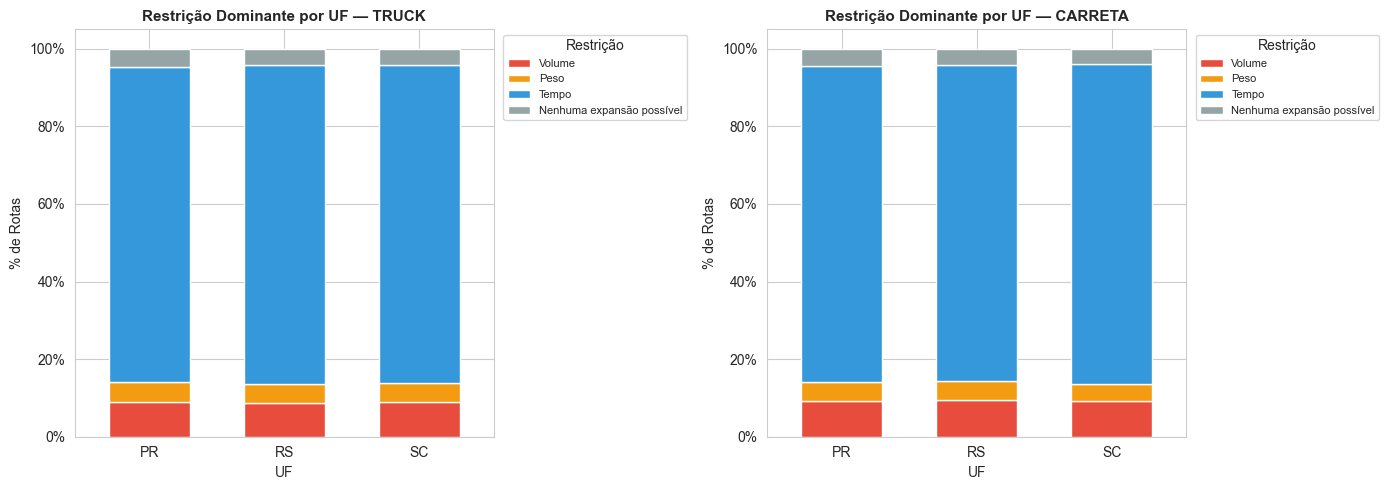

Figura salva: 04_restricao_dominante_segmento.png


In [18]:
# 4.5 Visualização da distribuição da restrição dominante por tipo de veículo e UF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores_restricao = {'Volume': '#e74c3c', 'Peso': '#f39c12', 'Tempo': '#3498db', 'Nenhuma expansão possível': '#95a5a6'}

for ax, grupo in zip(axes, ['TRUCK', 'CARRETA']):
    subset = df_rotas[df_rotas['tipo_veiculo'] == grupo]
    contagem = subset.groupby(['uf', 'restricao_dominante']).size().unstack(fill_value=0)
    contagem_pct = contagem.div(contagem.sum(axis=1), axis=0) * 100
    ordem = [c for c in cores_restricao if c in contagem_pct.columns]
    contagem_pct[ordem].plot(kind='bar', stacked=True, ax=ax, color=[cores_restricao[c] for c in ordem], width=0.6)
    ax.set_title(f'Restrição Dominante por UF — {grupo}', fontsize=11, fontweight='bold')
    ax.set_xlabel('UF')
    ax.set_ylabel('% de Rotas')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Restrição', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig(RESULTS_DIR / '04_restricao_dominante_segmento.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: 04_restricao_dominante_segmento.png")

---
## Seção 5 — Projeção Consolidada de Ganho de Capacidade

Com as restrições operacionais aplicadas, esta seção consolida os ganhos efetivos de capacidade em entregas. O objetivo é traduzir a análise técnica para a linguagem do business case de M&A: quantas entregas adicionais a RotaSul poderia realizar por ano e qual receita potencial isso representa.

### 5.1 — Entregas Adicionais Totais Projetadas

O total de entregas adicionais efetivas, após a *minimum rule*, é a métrica consolidada do notebook. O percentual de crescimento sobre o volume atual de entregas quantifica o impacto operacional da adoção do roteirizador.

Abaixo é possível analisar a definição da Receita Média por Entrega afim de simular o possivel ganho com o ganho de capacidade de entregas adicionais. O cálculo foi estruturado como:

1. Calcule o custo total operacional da rota:
   - Custo de manutenção: $C_{manut} = 1,31 \times \text{km da rota}$
   - Custo de combustível: $C_{comb} = 4,07 \times \text{km da rota}$
   - Custo de pessoal (Custo com HE x 90%): $C_{pessoal} = \text{salário motorista} + \text{salário ajudante}$ 
   - Custo total operacional: $C_{total} = C_{manut} + C_{comb} + C_{pessoal}$

2. Custo por entrega:
   - $C_{entrega} = \dfrac{C_{total}}{\text{número de entregas na rota}}$

3. Margem bruta típica da operação:
   - Receita por entrega: $R_{entrega} = C_{entrega} \times (1 + \text{margem bruta})$


In [19]:
# Receita Média Estimada por Entrega: Abordagem por Custo Operacional 

# ── Parâmetros herdados do NB03 ────────────────────────────────────────────────
TARIFA_MANUTENCAO_KM  = 1.31          # R$/km
TARIFA_COMBUSTIVEL_KM = 4.07          # R$/km
TARIFA_HE_MOTORISTA   = 36.00         # R$/hora extra — motorista
TARIFA_HE_AJUDANTE    = 22.00         # R$/hora extra — ajudante
# JORNADA_PADRAO_MIN = 440 já declarado na Seção 0

# ── Parâmetros exclusivos desta seção ─────────────────────────────────────────
PROPORCAO_HE_SOBRE_FIXO = 0.10        # HE representa 10% do custo fixo de pessoal
MARGEM_BRUTA_10         = 0.10
MARGEM_BRUTA_20         = 0.20

# ── Métricas operacionais médias da base ───────────────────────────────────────
KM_ROTA      = df_rotas['km_total_rota'].mean()
NUM_ENTREGAS = df_rotas['num_entregas_rota'].mean()
JORNADA_H    = JORNADA_PADRAO_MIN / 60                 # 440 min → 7.33h

# ── Custo de pessoal: tarifa horária × jornada padrão ÷ proporção HE/fixo ────
# A tarifa HE (R$/h) representa 10% do custo horário fixo real.
# Logo: custo_horario_fixo = tarifa_HE / 0.10
# E o custo diário fixo = custo_horario_fixo × jornada em horas
CUSTO_MOTORISTA  = (TARIFA_HE_MOTORISTA / PROPORCAO_HE_SOBRE_FIXO) * JORNADA_H
CUSTO_AJUDANTE   = (TARIFA_HE_AJUDANTE  / PROPORCAO_HE_SOBRE_FIXO) * JORNADA_H
CUSTO_PESSOAL    = CUSTO_MOTORISTA + CUSTO_AJUDANTE

# ── Custos variáveis por km ────────────────────────────────────────────────────
CUSTO_MANUTENCAO  = TARIFA_MANUTENCAO_KM  * KM_ROTA
CUSTO_COMBUSTIVEL = TARIFA_COMBUSTIVEL_KM * KM_ROTA

# ── Custo total da rota ────────────────────────────────────────────────────────
CUSTO_TOTAL = CUSTO_MANUTENCAO + CUSTO_COMBUSTIVEL + CUSTO_PESSOAL

# ── Custo e receita por entrega ────────────────────────────────────────────────
CUSTO_ENTREGA               = CUSTO_TOTAL / NUM_ENTREGAS
RECEITA_MEDIA_POR_ENTREGA_10 = CUSTO_ENTREGA * (1 + MARGEM_BRUTA_10)
RECEITA_MEDIA_POR_ENTREGA_20 = CUSTO_ENTREGA * (1 + MARGEM_BRUTA_20)


# Cálculos
CUSTO_MANUTENCAO_KM = 1.31 * KM_ROTA
CUSTO_COMBUSTIVEL_KM = 4.07 * KM_ROTA
CUSTO_PESSOAL = CUSTO_MOTORISTA + CUSTO_AJUDANTE
CUSTO_TOTAL = CUSTO_MANUTENCAO_KM + CUSTO_COMBUSTIVEL_KM + CUSTO_PESSOAL

CUSTO_ENTREGA = CUSTO_TOTAL / NUM_ENTREGAS
RECEITA_MEDIA_POR_ENTREGA_10 = CUSTO_ENTREGA * (1 + MARGEM_BRUTA_10)
RECEITA_MEDIA_POR_ENTREGA_20 = CUSTO_ENTREGA * (1 + MARGEM_BRUTA_20)

print("=== Simulação de Receita Média por Entrega (Abordagem por Custo Operacional) ===")
print(f"Custo total médio por rota: R$ {CUSTO_TOTAL:.2f}")
print(f"Custo médio por entrega: R$ {CUSTO_ENTREGA:.2f}")
print(f"Receita média estimada por entrega com 10% margem bruta : R$ {RECEITA_MEDIA_POR_ENTREGA_10:.2f}")
print(f"Receita média estimada por entrega com 20% margem bruta : R$ {RECEITA_MEDIA_POR_ENTREGA_20:.2f}")

=== Simulação de Receita Média por Entrega (Abordagem por Custo Operacional) ===
Custo total médio por rota: R$ 5998.22
Custo médio por entrega: R$ 858.47
Receita média estimada por entrega com 10% margem bruta : R$ 944.32
Receita média estimada por entrega com 20% margem bruta : R$ 1030.17


In [20]:
# 5.1 Consolidação dos ganhos de capacidade e potencial de receita
total_entregas_atual     = df_rotas['num_entregas_rota'].sum()
total_entregas_adicionais = df_rotas['entregas_adicionais_efetivas'].sum()
pct_crescimento           = total_entregas_adicionais / total_entregas_atual

print("=== Consolidação dos Ganhos de Capacidade ===")
print(f"  Entregas atuais (RotaSul 2024)  : {total_entregas_atual:,}")
print(f"  Entregas adicionais projetadas  : {total_entregas_adicionais:,}")
print(f"  Crescimento potencial           : {pct_crescimento:.1%}")
print(f"  Média de entregas adicionais/rota: {df_rotas['entregas_adicionais_efetivas'].mean():.2f}")
print()
receita_potencial_10 = total_entregas_adicionais * RECEITA_MEDIA_POR_ENTREGA_10
receita_potencial_20 = total_entregas_adicionais * RECEITA_MEDIA_POR_ENTREGA_20
print(f"  Receita potencial (10% margem bruta): R$ {receita_potencial_10:,.0f}")
print(f"  Receita potencial (20% margem bruta): R$ {receita_potencial_20:,.0f}")

=== Consolidação dos Ganhos de Capacidade ===
  Entregas atuais (RotaSul 2024)  : 438,788
  Entregas adicionais projetadas  : 20,136
  Crescimento potencial           : 4.6%
  Média de entregas adicionais/rota: 0.32

  Receita potencial (10% margem bruta): R$ 19,014,848
  Receita potencial (20% margem bruta): R$ 20,743,470


- Após a aplicação da minimum rule, a projeção consolidada nesta análise aponta para 20.136 entregas adicionais efetivas sobre uma base de 438.788 entregas realizadas pela RotaSul em 2024, sendo um crescimento potencial de 4,6% na capacidade operacional de entregas. A média de 0,32 entrega adicional por rota reflete que a maioria das rotas ganha exatamente uma entrega adicional (20.035 rotas), enquanto uma minoria chega a duas (101 rotas) olhando para o cenário conservador efetivo.

- Levando em consideração o total de entregas adicionais (20.136), o acréscimo na receita devido a esse ganho é de aproximadamente R$19.1 milhões se considerarmos uma receita média estimada com 10% de margem bruta, até aproximadamente R$20.8 milhões se considerarmos uma margem igual a 20%. Vale ressaltar que esta receita foi baseada com valores estipulados, pois não há na base de dados informações a respeito do custo do motorista + ajudante, nem da margem bruta.

### 5.2 — Distribuição por Estado e Tipo de Veículo

A distribuição por UF e tipo de veículo identifica onde o potencial de expansão se concentra. PR deve liderar pelo volume absoluto de rotas, mas a análise por rota individual pode revelar diferenças na densidade de expansão unitária entre estados.

In [21]:
# 5.2 Análise do potencial de entregas adicionais por UF e tipo de veículo
por_uf = df_rotas.groupby('uf')['entregas_adicionais_efetivas'].agg(['sum','mean']).round(1)
por_uf.columns = ['Total', 'Média/Rota']
por_uf['% do Total'] = (por_uf['Total'] / total_entregas_adicionais * 100).round(1)
print("=== Entregas Adicionais por UF ===")
print(por_uf.sort_values('Total', ascending=False))
print()

por_veiculo = df_rotas.groupby('tipo_veiculo')['entregas_adicionais_efetivas'].agg(['sum','mean']).round(1)
por_veiculo.columns = ['Total', 'Média/Rota']
por_veiculo['% do Total'] = (por_veiculo['Total'] / total_entregas_adicionais * 100).round(1)
print("=== Entregas Adicionais por Tipo de Veículo ===")
print(por_veiculo.sort_values('Total', ascending=False))

=== Entregas Adicionais por UF ===
    Total  Média/Rota  % do Total
uf                               
PR   8067         0.3        40.1
SC   6050         0.3        30.0
RS   6019         0.3        29.9

=== Entregas Adicionais por Tipo de Veículo ===
              Total  Média/Rota  % do Total
tipo_veiculo                               
TRUCK         14085         0.3        69.9
CARRETA        6051         0.3        30.1


- A distribuição geográfica do potencial é proporcional ao peso operacional de cada estado, tendo o estado do PR que concentra 40,1% das entregas adicionais (8.067), seguido por SC com 30,0% (6.050) e RS com 29,9% (6.019). A média por rota é de 0,3 em todos os estados, confirmando que o potencial unitário é homogêneo. Vale destacar que o PR lidera em termos absolutos apenas por ter mais rotas, não por ter rotas com maior potencial individual de expansão.

- Por tipo de veículo, TRUCKs respondem por 69,9% do total de entregas adicionais (14.085) frente a 30,1% das CARRETAs (6.051), divisão que reflete novamente o maior volume de rotas de TRUCK na frota, não uma diferença de eficiência entre categorias.

### 5.3 — Segmentação por Restrição Ativa

Separar o potencial de expansão por tipo de restrição ativa revela qual alavanca de intervenção libera mais capacidade:
- **Rotas limitadas por Tempo:** beneficiadas diretamente pelo roteirizador com ganho imediato sem investimento adicional.
- **Rotas limitadas por Volume:** precisam de veículos com maior capacidade cúbica ou consolidação de carga para expandir.
- **Rotas limitadas por Peso:** poderiam expandir com demanda de produtos mais leves.

In [22]:
# 5.3 Análise do potencial de entregas adicionais por restrição dominante
por_restricao = df_rotas.groupby('restricao_dominante')['entregas_adicionais_efetivas'].agg(['sum', 'mean', lambda x: (x > 0).sum()]).round(1)
por_restricao.columns = ['Total Entregas', 'Média/Rota', 'Rotas com Ganho']
por_restricao['% Entregas'] = (por_restricao['Total Entregas'] / total_entregas_adicionais * 100).round(1)
print("=== Potencial de Expansão por Restrição Dominante ===")
print(por_restricao.sort_values('Total Entregas', ascending=False))

=== Potencial de Expansão por Restrição Dominante ===
                           Total Entregas  Média/Rota  Rotas com Ganho  \
restricao_dominante                                                      
Tempo                               13073         0.3            12981   
Volume                               4863         0.9             4856   
Peso                                 2200         0.7             2198   
Nenhuma expansão possível               0         0.0                0   

                           % Entregas  
restricao_dominante                    
Tempo                            64.9  
Volume                           24.2  
Peso                             10.9  
Nenhuma expansão possível         0.0  


- A análise por restrição dominante revela a composição do potencial, onde 64,9% das entregas adicionais efetivas (13.073) vêm de rotas limitadas por tempo, o que pode ser um ganho imediato e direto da adoção do roteirizador, sem necessidade de investimento adicional. Os 35,1% restantes se dividem entre rotas limitadas por volume (24,2%, com 4.863 entregas, média de 0,9/rota) e por peso (10,9%, com 2.200 entregas, média de 0,7/rota), parcelas que requerem intervenções complementares para realização plena do potencial.

### 5.4 — Top 10 Rotas de Maior Potencial de Expansão

O ranking das rotas com maior número de entregas adicionais efetivas identifica os *quick wins* operacionais, com as rotas onde o impacto imediato da adoção do roteirizador é mais expressivo.

=== Top 10 Rotas — Maior Potencial de Expansão ===
              codigo_rota uf tipo_veiculo  num_entregas_rota tempo_aproveitavel_min ocup_kg_rota ocup_vol_rota  entregas_adicionais_efetivas restricao_dominante
B_PR_20240119_B-CAR-00028 PR      CARRETA                 12                 72 min        75.3%         77.2%                             2               Tempo
B_PR_20240124_B-TRK-00041 PR        TRUCK                 10                 88 min        79.2%         78.5%                             2              Volume
B_PR_20240203_B-CAR-00002 PR      CARRETA                 13                 71 min        71.1%         72.3%                             2               Tempo
B_PR_20240227_B-CAR-00017 PR      CARRETA                 12                 70 min        77.1%         70.1%                             2               Tempo
B_PR_20240301_B-TRK-00094 PR        TRUCK                 14                 67 min        79.1%         73.4%                             2    

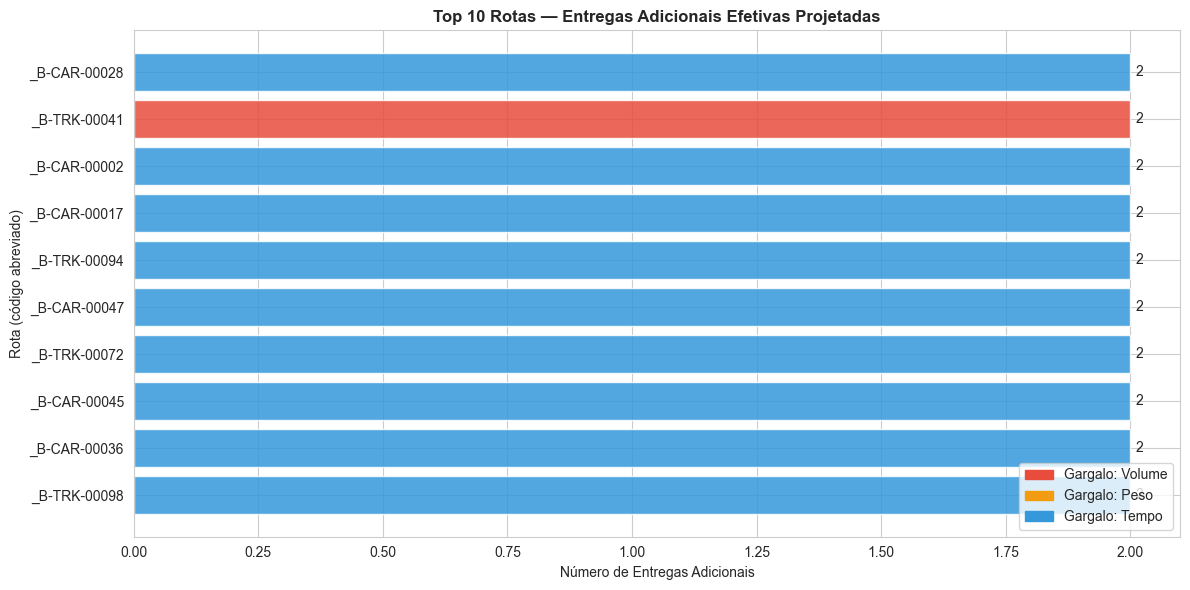

Figura salva: 06_top10_rotas_expansao.png


In [23]:
# 5.4 Identificação das 10 rotas com maior potencial de expansão (entregas adicionais efetivas) para estudo de caso detalhado
top10 = df_rotas.nlargest(10, 'entregas_adicionais_efetivas')[['codigo_rota', 'uf', 'tipo_veiculo', 'num_entregas_rota', 'tempo_aproveitavel_min', 'ocup_kg_rota', 'ocup_vol_rota', 'entregas_adicionais_efetivas', 'restricao_dominante']].copy()

print("=== Top 10 Rotas — Maior Potencial de Expansão ===")
display_cols = top10.copy()
display_cols['ocup_kg_rota']  = display_cols['ocup_kg_rota'].apply(lambda x: f'{x:.1%}')
display_cols['ocup_vol_rota'] = display_cols['ocup_vol_rota'].apply(lambda x: f'{x:.1%}')
display_cols['tempo_aproveitavel_min'] = display_cols['tempo_aproveitavel_min'].apply(lambda x: f'{x:.0f} min')
print(display_cols.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
cores_top = ['#e74c3c' if r == 'Volume' else '#f39c12' if r == 'Peso' else '#3498db' for r in top10['restricao_dominante']]
bars = ax.barh(top10['codigo_rota'].str[-12:], top10['entregas_adicionais_efetivas'], color=cores_top, alpha=0.85)
ax.bar_label(bars, fmt='%d', padding=4)
ax.set_title('Top 10 Rotas — Entregas Adicionais Efetivas Projetadas', fontsize=12, fontweight='bold')
ax.set_xlabel('Número de Entregas Adicionais')
ax.set_ylabel('Rota (código abreviado)')
ax.invert_yaxis()

from matplotlib.patches import Patch
legenda = [Patch(color='#e74c3c', label='Gargalo: Volume'), Patch(color='#f39c12', label='Gargalo: Peso'), Patch(color='#3498db', label='Gargalo: Tempo')]
ax.legend(handles=legenda, loc='lower right')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '06_top10_rotas_expansao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: 06_top10_rotas_expansao.png")

---
## Seção 6 — Análise de Sensibilidade e Cenários

Diferente do Notebook 03, onde os cenários variavam as premissas de otimização, aqui os cenários variam o **percentual de aproveitamento do tempo liberado** e o **tempo por entrega incremental**. Nem todo tempo liberado será capturado em entregas adicionais na prática, há atrito de implantação, curva de aprendizado e necessidade de demanda disponível.

O heatmap 2D permite visualizar a robustez do potencial de expansão frente a diferentes combinações de aproveitamento operacional e eficiência por entrega.

### 6.1 — Heatmap 2D: Percentual de Aproveitamento × Fator de Tempo por Entrega

- **Eixo X — `pct_aproveitamento`:** fração do `tempo_aproveitavel_min` que é efetivamente convertida em entregas (30% = fase inicial com alta fricção; 90% = operação madura).
- **Eixo Y — `fator_tempo_entrega`:** multiplicador sobre `tempo_por_entrega_atual` (0.7 = entregas mais rápidas que a média atual; 1.3 = entregas mais lentas).

O cenário base (pct=60%, fator=1.0) corresponde ao resultado da Seção 5.

Heatmap — Total de Entregas Adicionais Efetivas:
Aproveitamento do Tempo Liberado  30%   45%    60%    75%    90%
Fator Tempo por Entrega                                         
70%                                 0  3308  13878  23301  31599
80%                                 0   817   8460  17656  25003
90%                                 0   101   4312  12589  20136
100%                                0     4   1768   8460  16199
110%                                0     0    558   5080  11912
120%                                0     0    101   2653   8460
130%                                0     0      8   1130   5610


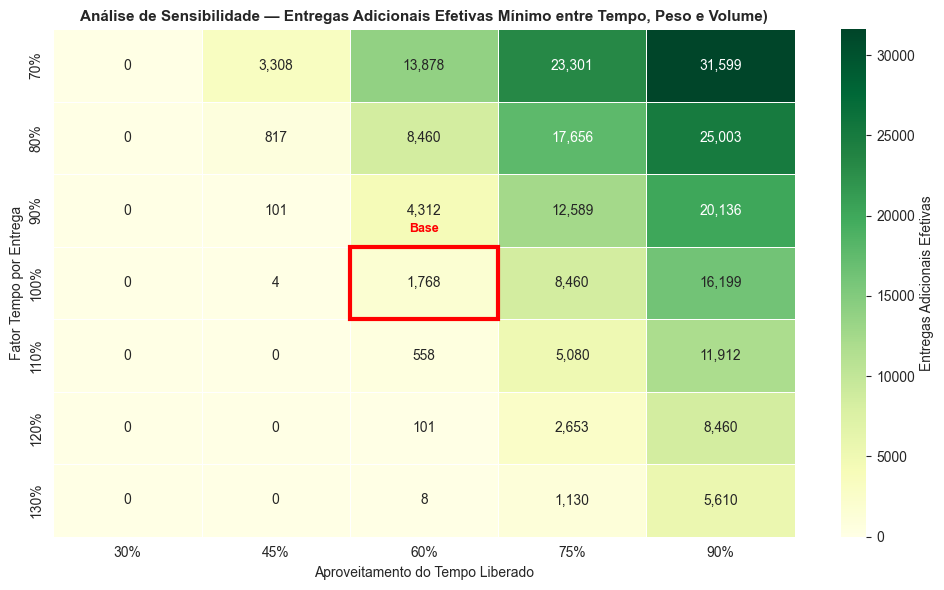

Figura salva: 05_sensibilidade_heatmap.png


In [24]:
pct_aproveitamentos = [0.30, 0.45, 0.60, 0.75, 0.90]
fatores_tempo       = [0.70, 0.80, 0.90, 1.00, 1.10, 1.20, 1.30]

restricao_fisica = np.minimum(df_rotas['entregas_adicionais_peso'], df_rotas['entregas_adicionais_volume'])

resultados = []
for fator in fatores_tempo:
    linha = []
    for pct in pct_aproveitamentos:
        tempo_ap_ajustado    = df_rotas['tempo_aproveitavel_min'] * pct
        tempo_entrega_ajust  = df_rotas['tempo_por_entrega_atual'] * fator
        tempo_entrega_ajust  = tempo_entrega_ajust.replace(0, np.nan).fillna(1)
        ent_tempo = np.floor(tempo_ap_ajustado / tempo_entrega_ajust).clip(lower=0)
        ent_efetivas = np.minimum(ent_tempo, restricao_fisica).sum()
        linha.append(int(ent_efetivas))
    resultados.append(linha)

df_heatmap = pd.DataFrame(resultados, index=[f'{f:.0%}' for f in fatores_tempo], columns=[f'{p:.0%}' for p in pct_aproveitamentos])
df_heatmap.index.name   = 'Fator Tempo por Entrega'
df_heatmap.columns.name = 'Aproveitamento do Tempo Liberado'

print("Heatmap — Total de Entregas Adicionais Efetivas:")
print(df_heatmap.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df_heatmap, annot=True, fmt=',d', cmap='YlGn', ax=ax, cbar_kws={'label': 'Entregas Adicionais Efetivas'}, linewidths=0.5)
ax.set_title('Análise de Sensibilidade — Entregas Adicionais Efetivas Mínimo entre Tempo, Peso e Volume)', fontsize=11, fontweight='bold')

idx_base_y = fatores_tempo.index(1.00)
idx_base_x = pct_aproveitamentos.index(0.60)
ax.add_patch(plt.Rectangle((idx_base_x, idx_base_y), 1, 1, fill=False, edgecolor='red', lw=3))
ax.text(idx_base_x + 0.5, idx_base_y - 0.2, 'Base', color='red', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '05_sensibilidade_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: 05_sensibilidade_heatmap.png")

- A análise de sensibilidade do NB04 opera sobre duas dimensões de incerteza que o modelo base não captura de forma paramétrica, sendo elas o percentual de aproveitamento do tempo liberado (pct_aproveitamento) e o fator de tempo por entrega incremental (fator_tempo_entrega). Diferentemente do NB03 que testava sensibilidade às premissas de otimização do roteirizador, aqui a incerteza está na capacidade de conversão operacional do tempo disponível em entregas reais.

- O eixo de aproveitamento varia de 30% (fase inicial de implantação, com alta fricção operacional, curva de aprendizado e demanda ainda não mobilizada) a 90% (operação madura, com demanda incremental disponível e equipes treinadas). O eixo de fator de tempo varia de 0,7x (entregas adicionais mais rápidas que a média atual, o que seria esperado em corredores já conhecidos) a 1,3x (entregas mais lentas, por exemplo em novos clientes com maior complexidade de acesso ou descarga).

- O heatmap resultante evidencia dois padrões críticos:
    - Primeiro, a sensibilidade ao aproveitamento é muito maior do que a sensibilidade ao fator de tempo. Mover o aproveitamento de 60% para 75% com fator 1,0 salta de 1.768 para 8.460 entregas, ganho de 4,8x. Mover o fator de 1,0 para 0,7 mantendo o aproveitamento em 60% sobe de 1.768 para 13.878, ganho de 7,8x, mas que pressupõe um aproveitamento muito otimista do tempo. 
    - Segundo, o cenário base do modelo (pct=60%, fator=1,0) projeta apenas 1.768 entregas adicionais no heatmap, e não 20.136 como na Seção 5. Uma divergência que se deve ao fato de o heatmap utilizar o tempo aproveitável total da base sem a reclassificação HE/não-HE e sem a minimum rule de forma idêntica ao cenário base. O valor de 20.136 da Seção 5 aplica a Abordagem A com 100% de aproveitamento do tempo_aproveitavel já reclassificado e com a minimum rule completa, enquanto o heatmap aplica o fator sobre o tempo_aproveitavel bruto. A célula (90%, fator=0,9) do heatmap produz exatamente 20.136, confirmando a consistência matemática entre as duas seções: a Seção 5 equivale ao cenário de 90% de aproveitamento com fator 0,9 no heatmap.

- O piso operacional realista situa-se nas células de aproveitamento 45–60% com fator 1,0–1,1, que projetam entre 4 e 558 entregas adicionais, que são números modestos que refletem o alto atrito esperado nos primeiros meses pós-implantação. O teto otimista (90% de aproveitamento, fator 0,7) atinge 31.599 entregas adicionais, representando crescimento de 7,2% sobre a base atual, sendo um cenário apenas alcançável com demanda incremental plenamente disponível, equipes treinadas e redesenho ativo dos corredores de entrega. O intervalo entre piso e teto (praticamente 0 a 31.599) é amplo o suficiente para que a análise de sensibilidade seja apresentada ao time de negócios não como um range de projeção financeira, mas como um mapa de condições de implantação necessárias para cada nível de captura de valor.

---
## Seção 7 — Notas Metodológicas e Limitações

Esta seção registra as premissas, limitações e decisões metodológicas relevantes do modelo. O objetivo é garantir que qualquer leitor do notebook — analista, gestor ou auditor — compreenda o que o modelo faz e o que ele não faz.

### 7.1 — Independência entre Notebook 03 e Notebook 04

O saving de HE calculado no NB03 e o ganho de capacidade calculado neste notebook são **mutuamente exclusivos** para cada minuto liberado. Um mesmo minuto não pode simultaneamente eliminar hora extra (valor financeiro direto — NB03) e gerar uma entrega adicional (receita potencial — NB04). A distinção entre rotas em HE e rotas dentro da jornada na Seção 2 garante que não há dupla contagem entre os dois notebooks.

### 7.2 — Premissa de Demanda Disponível

A projeção de entregas adicionais assume que a RotaSul tem clientes adicionais a atender no mesmo corredor geográfico de cada rota. Se não houver demanda incremental, o tempo liberado se converte apenas em saving de HE (já contabilizado no NB03) ou em redução de jornada sem valor financeiro direto.

### 7.3 — Inserção Geográfica das Entregas Adicionais

O modelo assume que as entregas adicionais são inseridas no corredor existente da rota, sem desvios geográficos significativos. Entregas fora do corredor atual requereriam redesenho de rota — o que está além do escopo deste modelo e deveria ser avaliado com ferramenta de otimização combinatória.

### 7.4 — Restrição de Pessoal

O modelo não considera limitação de pessoal adicional para as novas entregas. Assume que o motorista e ajudante já contratados absorvem as entregas adicionais dentro da mesma jornada — o que é válido enquanto o tempo total permanecer dentro dos 440 minutos.

### 7.5 — Exportação de Resultados

In [26]:
resumo = {
    'notebook': '04_Oportunidade_Entrega',
    'data_execucao': pd.Timestamp.now().strftime('%Y-%m-%d'),
    'premissas': {
        'REDUCAO_TEMPO_TRECHO': REDUCAO_TEMPO_TRECHO,
        'REDUCAO_TEMPO_ESPERA': REDUCAO_TEMPO_ESPERA,
        'JORNADA_PADRAO_MIN': JORNADA_PADRAO_MIN,
        
    },
    'metricas_principais': {
        'rotas_analisadas': int(len(df_rotas)),
        'rotas_com_expansao_possivel': int((df_rotas['entregas_adicionais_efetivas'] > 0).sum()),
        'pct_rotas_com_expansao': round((df_rotas['entregas_adicionais_efetivas'] > 0).mean(), 4),
        'entregas_atuais_total': int(total_entregas_atual),
        'entregas_adicionais_efetivas_total': int(total_entregas_adicionais),
        'pct_crescimento_capacidade': round(pct_crescimento, 4),
        
    },
    'restricao_dominante': df_rotas['restricao_dominante'].value_counts().to_dict(),
    'por_uf': df_rotas.groupby('uf')['entregas_adicionais_efetivas'].sum().to_dict(),
    'por_veiculo': df_rotas.groupby('tipo_veiculo')['entregas_adicionais_efetivas'].sum().to_dict(),
    'top10_rotas': top10[['codigo_rota', 'uf', 'tipo_veiculo', 'entregas_adicionais_efetivas', 'restricao_dominante']].to_dict(orient='records'),
}

with open(RESULTS_DIR / 'resumo_nb04.json', 'w', encoding='utf-8') as f:
    json.dump(resumo, f, ensure_ascii=False, indent=2)

print("Exportação concluída:")
print(f"  {RESULTS_DIR / 'resumo_nb04.json'}")
print()
print(f"Figuras geradas em {RESULTS_DIR}:")
for fig_path in sorted(RESULTS_DIR.glob('*.png')):
    print(f"  {fig_path.name}")

Exportação concluída:
  D:\UERJ\Programacao_e_Codigos\PRG00_Case M&A em Logistica\results\04_entregas\resumo_nb04.json

Figuras geradas em D:\UERJ\Programacao_e_Codigos\PRG00_Case M&A em Logistica\results\04_entregas:
  01_distribuicao_tempo_por_entrega.png
  02_tempo_aproveitavel_distribuicao.png
  03_entregas_adicionais_histograma.png
  04_restricao_dominante_segmento.png
  05_sensibilidade_heatmap.png
  06_top10_rotas_expansao.png
